# Getting started with `ocean-skill`

Model–data comparison for ocean models: read two things through catalogs, say which is
the **reference** and which is the **test**, and get aligned fields, skill metrics and
figures.

This notebook is meant to be **edited**. Every cell is a real call against real data —
change a variable, a depth, a source name, and re-run.

### The three ideas

| idea | what it means |
|---|---|
| **reference / test** | Roles assigned *at comparison time*, not in the catalog. `difference = test − reference`, alignment lands on the coarser grid, and styling follows (reference solid, test dashed). Any pairing works: obs↔model, model↔model, obs↔obs. |
| **catalogs** | Sources are intake v2 catalogs found automatically along a search path: packaged defaults → `$OCEAN_SKILL_CATALOGS` team dir → `~/.ocean-skill/catalogs/` yours → `./catalogs/` this project. Each entry carries metadata — `featureType`, variable→CF-standard_name map, extents — so compatibility can be checked before reading a byte. |
| **standard names** | Variables are addressed by CF standard_name, not file-specific names. `mole_concentration_of_nitrate_in_sea_water` works whether the file calls it `NO3` or `n_an`. |

### The data used here

This notebook uses two **local** sources so it runs anywhere without network:

- **test**: `roms_example_combined` — a small Gulf of Mexico ROMS run (roms-tools example)
- **reference**: `woa23_temperature_month01`, `woa23_salinity_month01` — World Ocean
  Atlas 2023 January climatology

WOA files are fetched once and cached locally, so re-runs are offline and fast. Swap in
your own sources by name and everything below works the same — e.g. a run's BGC stream
against the nutrient entries:

```python
osk.compare(reference=["woa23_nitrate_month01", "woa23_phosphate_month01"],
            test="GOM_bgc",
            variables=["mole_concentration_of_nitrate_in_sea_water",
                       "mole_concentration_of_phosphate_in_sea_water"])
```

> GLODAP is also catalogued, but it is an open-ocean product that masks most marginal
> seas — only ~8% of the Gulf of Mexico versus WOA's ~58% — so WOA is the right reference
> for this domain.

## 1. What's available?

Catalogs are discovered from four tiers (lowest to highest precedence): the shipped
defaults, `$OCEAN_SKILL_CATALOGS` (a team/shared directory, or `osk.catalog.add_search_path(...)`
in code), your own `~/.ocean-skill/catalogs/`, and this project's `./catalogs/*.yaml` —
drop a file in the tier that fits and it appears. Check what's actually on the search
path any time with `osk.catalog.search_paths()`.

In [1]:
import ocean_skill as osk

osk.catalogs

Importing intake_erddap.erddap_cat:ERDDAPCatalogReader as part of processing intake entrypoints failed
(No module named 'cf_pandas')


Importing intake_erddap.erddap:GridDAPReader as part of processing intake entrypoints failed
(No module named 'cf_pandas')


Importing intake_erddap.erddap:TableDAPReader as part of processing intake entrypoints failed
(No module named 'cf_pandas')


<ocean_skill.catalogs: 81 sources>
  GLODAPv2.2016b Mapped Climatologies: glodap
  ROMS: GOM_lowres
  World Ocean Atlas 2023 (1 deg) — annual + monthly climatology: woa23_nitrate_annual, woa23_nitrate_month01, woa23_nitrate_month02, woa23_nitrate_month03, woa23_nitrate_month04, woa23_nitrate_month05, woa23_nitrate_month06, woa23_nitrate_month07, woa23_nitrate_month08, woa23_nitrate_month09, woa23_nitrate_month10, woa23_nitrate_month11, woa23_nitrate_month12, woa23_oxygen_annual, woa23_oxygen_month01, woa23_oxygen_month02, woa23_oxygen_month03, woa23_oxygen_month04, woa23_oxygen_month05, woa23_oxygen_month06, woa23_oxygen_month07, woa23_oxygen_month08, woa23_oxygen_month09, woa23_oxygen_month10, woa23_oxygen_month11, woa23_oxygen_month12, woa23_phosphate_annual, woa23_phosphate_month01, woa23_phosphate_month02, woa23_phosphate_month03, woa23_phosphate_month04, woa23_phosphate_month05, woa23_phosphate_month06, woa23_phosphate_month07, woa23_phosphate_month08, woa23_phosphate_month09, woa

`osk.find` searches the metadata rather than the data, so it's instant:

In [2]:
TEMP = "sea_water_potential_temperature"
osk.find(standard_name=TEMP)[:6]

['glodap', 'roms_example_combined']

## 2. Reading a source

`osk.read` returns a CF-standardized object: an `xarray.Dataset` for gridded data
(a `pandas.DataFrame` for point featureTypes). For ROMS this also attaches the grid,
decodes `ocean_time`, masks land, and builds the `z_rho` depth coordinate.

In [3]:
model = osk.read("roms_example_combined")
print("variables:", [v for v in model.data_vars][:6])
print("coords   :", list(model.coords))
model

variables: ['ocean_time', 'time_step', 'sea_surface_height_above_geoid', 'ubar', 'vbar', 'sea_water_x_velocity']
coords   : ['angle', 'mask_rho', 'h', 'sigma_r', 'Cs_r', 'lat_rho', 'lon_rho', 'lat_u', 'lon_u', 'lat_v', 'lon_v', 'lat_coarse', 'lon_coarse', 'time', 'lon', 'lat', 'z_rho']


<xarray.Dataset> Size: 128MB
Dimensions:                          (time: 31, auxil: 6, eta_rho: 82,
                                      xi_rho: 102, xi_u: 101, eta_v: 81,
                                      s_rho: 20, eta_coarse: 42, xi_coarse: 52,
                                      s_w: 21)
Coordinates: (12/17)
  * time                             (time) datetime64[s] 248B 2012-01-01 ......
    angle                            (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    mask_rho                         (eta_rho, xi_rho) int32 33kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    h                                (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    lat_rho                          (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    lon_rho                          (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    ...                               ...
    lat_u                            (eta_rho, xi_u) float64 66kB dask.array<chunksize=(82, 101), meta=np.ndarray>
    lon_u                            (eta_rho, xi_u) float64 66kB dask.array<chunksize=(82, 101), meta=np.ndarray>
    sigma_r                          (s_rho) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    Cs_r                             (s_rho) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    lat_coarse                       (eta_coarse, xi_coarse) float64 17kB dask.array<chunksize=(42, 52), meta=np.ndarray>
    lon_coarse                       (eta_coarse, xi_coarse) float64 17kB dask.array<chunksize=(42, 52), meta=np.ndarray>
Dimensions without coordinates: auxil, eta_rho, xi_rho, xi_u, eta_v, s_rho,
                                eta_coarse, xi_coarse, s_w
Data variables: (12/19)
    ocean_time                       (time) float64 248B dask.array<chunksize=(10,), meta=np.ndarray>
    time_step                        (time, auxil) int32 744B dask.array<chunksize=(10, 6), meta=np.ndarray>
    sea_surface_height_above_geoid   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(10, 82, 102), meta=np.ndarray>
    ubar                             (time, eta_rho, xi_u) float32 1MB dask.array<chunksize=(10, 82, 101), meta=np.ndarray>
    vbar                             (time, eta_v, xi_rho) float32 1MB dask.array<chunksize=(10, 81, 102), meta=np.ndarray>
    sea_water_x_velocity             (time, s_rho, eta_rho, xi_u) float32 21MB dask.array<chunksize=(10, 20, 82, 101), meta=np.ndarray>
    ...                               ...
    mask_u                           (eta_rho, xi_u) int32 33kB dask.array<chunksize=(82, 101), meta=np.ndarray>
    mask_v                           (eta_v, xi_rho) int32 33kB dask.array<chunksize=(81, 102), meta=np.ndarray>
    angle_coarse                     (eta_coarse, xi_coarse) float64 17kB dask.array<chunksize=(42, 52), meta=np.ndarray>
    mask_coarse                      (eta_coarse, xi_coarse) int32 9kB dask.array<chunksize=(42, 52), meta=np.ndarray>
    sigma_w                          (s_w) float32 84B dask.array<chunksize=(21,), meta=np.ndarray>
    Cs_w                             (s_w) float32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Attributes: (12/46)
    global_x:           100
    global_y:           80
    title:              Example run
    grid_file:          ROMS_TOOLS_INPUT_DATA/roms_grd.0.nc
    forcing_files:       ROMS_TOOLS_INPUT_DATA/roms_frc_201201.0.nc ROMS_TOOL...
    forcing_info:       
    ...                 ...
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        eeaca4861898a27443cd1f693811c321140ef58c
    type:               ROMS history file
    featureType:        grid
    ocean_skill_model:  roms

## 3. One comparison

A `Comparison` is a reference, a test, a variable and a selection. Nothing happens until
you ask for `.metrics()`, `.plot()` or `.aligned`.

In [4]:
c = osk.Comparison(
    aggregate={"time": "mean"},
    reference="woa23_temperature_month01",  # WOA January climatology (cached locally)
    test="roms_example_combined",           # the model run
    variable=TEMP,
    select={"depth": 0},                    # 0 m = surface
)
c

<Comparison sea_water_potential_temp roms_example_combined vs woa23_temperature_month01 @ 0 m>

`.metrics()` returns one flat record. `bias` and `rmse` are in the variable's units;
`corr` is the spatial correlation; `sigma_ratio` is test σ / reference σ (below 1 means
the model is under-dispersed — too smooth); `n` is the number of cells both members
share.

In [5]:
{k: round(v, 3) if isinstance(v, float) else v
 for k, v in c.metrics().items()
 if k in ("bias", "rmse", "corr", "sigma_ratio", "n")}

{'bias': -0.164, 'rmse': 0.659, 'corr': 0.952, 'sigma_ratio': 0.934, 'n': 175}

`.plot()` draws the standard row: **test | reference | difference**.

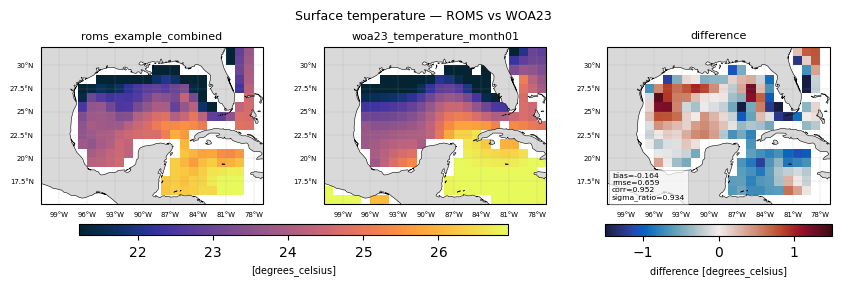

In [6]:
c.plot(title="Surface temperature — ROMS vs WOA23");

## 4. Several variables at once

`osk.compare` fans over variables (and depths, and sources). WOA ships one dataset per
variable, so you pass the entries and the variables together — each variable is paired
automatically with the reference that actually carries it, read from the catalog
metadata. No manual matching.

In [7]:
SALT = "sea_water_practical_salinity"

physics = osk.compare(
    aggregate={"time": "mean"},
    reference=["woa23_temperature_month01", "woa23_salinity_month01"],
    test="roms_example_combined",
    variables=[TEMP, SALT],
)
physics

<ComparisonSet: 2 comparisons>

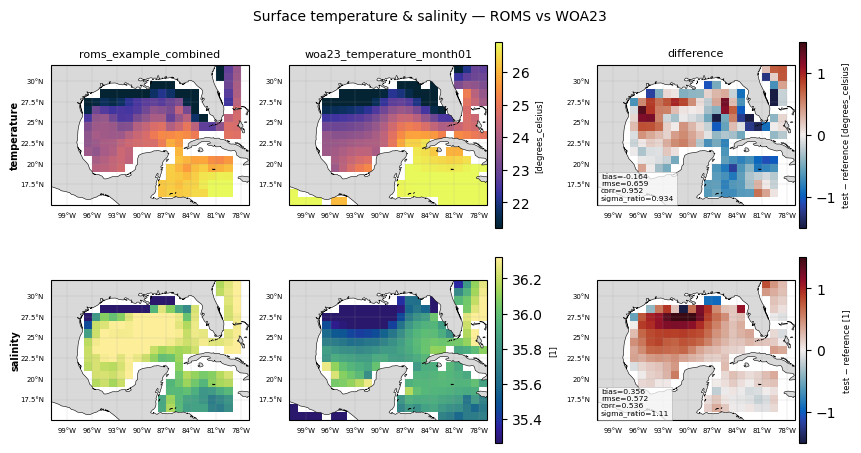

In [8]:
physics.plot(title="Surface temperature & salinity — ROMS vs WOA23");

**Names and units are reconciled for you** — `ocean_skill.units` handles three cases:

| case | example | what happens |
|---|---|---|
| same name | `sea_surface_height_above_geoid` | used directly |
| same species, different CF name + units | model `mole_concentration_of_nitrate_in_sea_water` (mmol m⁻³) vs WOA `moles_of_nitrate_per_unit_mass_in_sea_water` (µmol kg⁻¹) | matched, then converted using ρ = 1025 kg m⁻³ (a good approximation, not TEOS-10) |
| *near* equivalents | model `sea_water_potential_temperature` vs WOA `sea_water_temperature` | matched and tagged `approximate_match` — negligible at the surface, a few tenths of a degree by ~1000 m |

## 5. Several depths

Same call, different axis. Depths are metres; the model's s-coordinate field is
transformed onto them with xgcm.

/Users/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


/Users/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


/Users/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


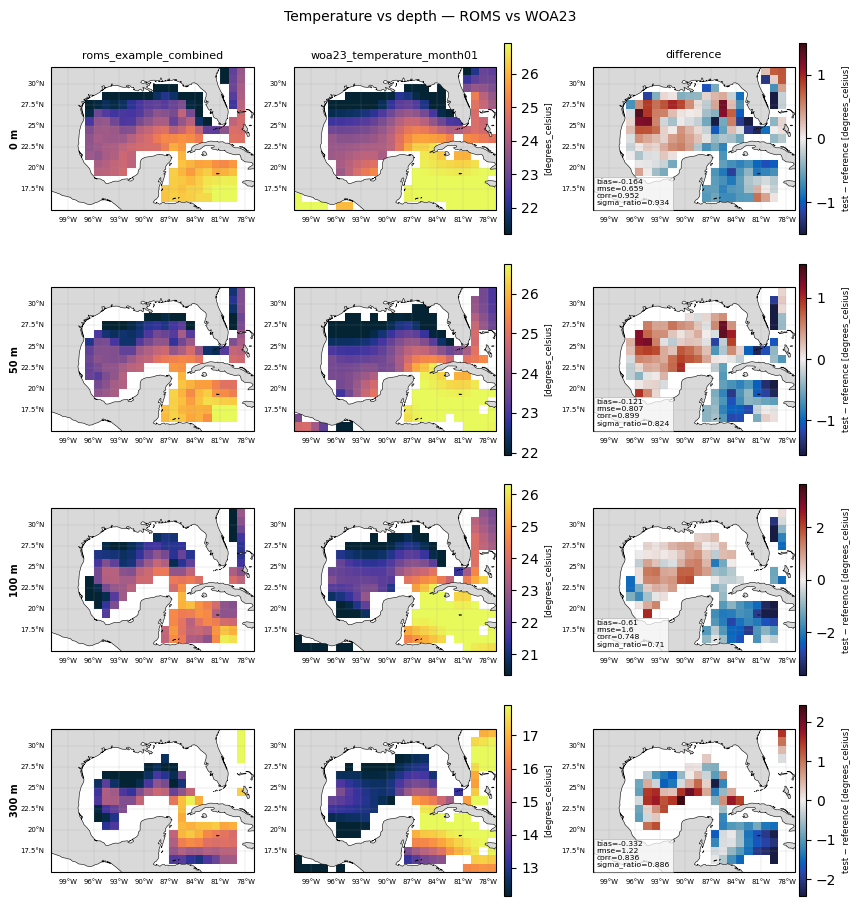

In [9]:
depths = osk.compare(
    aggregate={"time": "mean"},
    reference="woa23_temperature_month01",
    test="roms_example_combined",
    variables=[TEMP],
    depths=(0, 50, 100, 300),
)
depths.plot(title="Temperature vs depth — ROMS vs WOA23");

## 6. The metrics table

`.metrics()` on a set gives a tidy DataFrame — one row per comparison, ready for a
scorecard, a report, or a trend plot across runs.

In [10]:
df = depths.metrics()
df[["variable", "depth", "obs_depth", "bias", "rmse", "corr", "sigma_ratio", "n"]]

,variable,depth,obs_depth,bias,rmse,corr,sigma_ratio,n
0,sea_water_potential_temperature,0,0.0,-0.164210,0.659496,0.952285,0.933568,175
1,sea_water_potential_temperature,50,50.0,-0.120761,0.807129,0.899218,0.823703,147
2,sea_water_potential_temperature,100,100.0,-0.610479,1.603731,0.747664,0.709509,130
3,sea_water_potential_temperature,300,300.0,-0.331687,1.221524,0.836378,0.886063,99


In [11]:
depths.write_metrics("output/notebook", stem="temperature_depths")

PosixPath('output/notebook/metrics/temperature_depths.csv')

## 7. Summary diagrams

A field row shows one comparison in detail; these compress each comparison to a single
point so a whole set reads at a glance. **Use both** — they are complementary:

| | shows | misses |
|---|---|---|
| **Taylor** | correlation (angle) and standard deviation (radius); distance from the reference point is the centred RMSD | **bias entirely** — a model uniformly 5 °C too warm plots perfectly |
| **Target** | bias (y) against *signed* centred RMSD (x); distance from the origin is the normalized total RMSD | correlation, only implicitly |

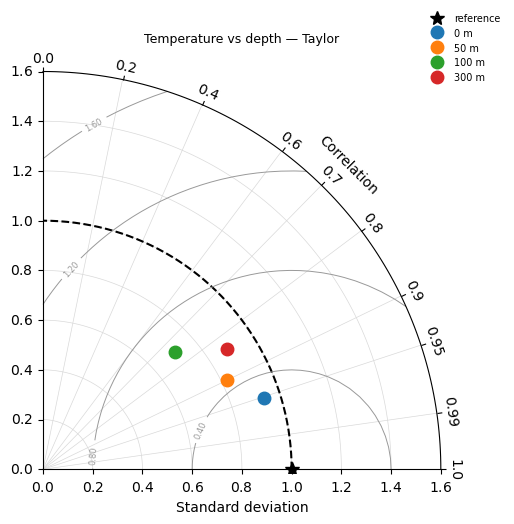

In [12]:
depths.taylor(title="Temperature vs depth — Taylor");

Points nearer the reference marker are better. Both axes are normalized by each
comparison's own reference standard deviation, so different variables and units can share
one diagram.

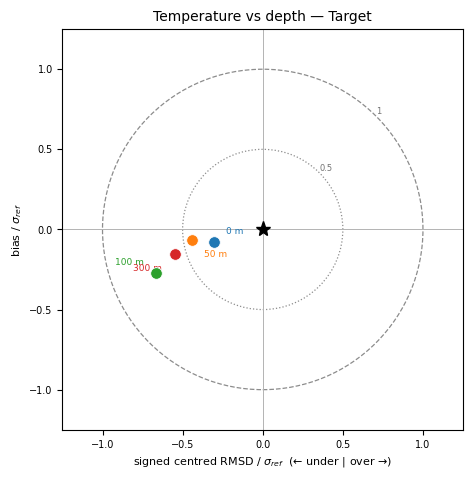

In [13]:
depths.target(title="Temperature vs depth — Target");

The Target diagram adds two things Taylor cannot show:

- **Bias** (y): all our points sit slightly *below* zero — the model is cool relative to
  WOA at every depth.
- **Dispersion** (x, signed): every point is on the **left**, meaning the model is
  under-dispersed — its spatial variability is smaller than observed. That is the single
  most consistent signal in this run, and Taylor alone would not name it.

Inside the unit circle the model beats the observed mean as a predictor; the dotted
circle at 0.5 is a conventional "good" threshold.

Both take the same styling arguments and a `save=` path, and work on any set — so the
multi-variable set from earlier plots just as well, one point per variable:

### Read them together

`.summary()` puts both on one figure, which is how they are usually presented:

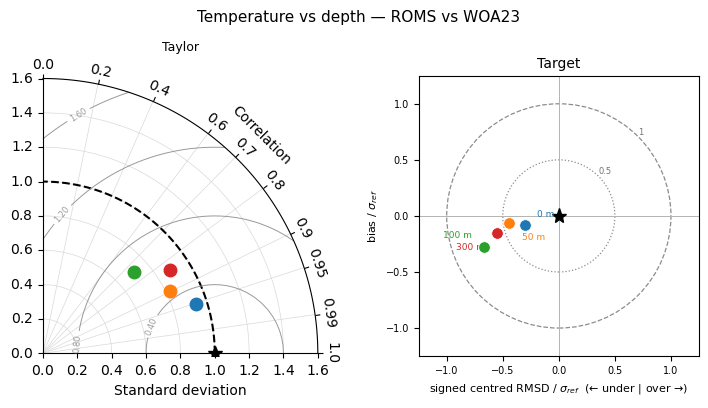

In [14]:
depths.summary(title="Temperature vs depth — ROMS vs WOA23");

### Several groups on one diagram

Style carries the grouping: **colour** for one dimension, **marker shape** for another.
Name any field of the metric records (`variable`, `depth`, `test`, `reference`), so a
single figure can hold several models across several regions without becoming
unreadable.

/Users/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


/Users/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/xgcm/grid.py:989: FutureWarning: From version 0.8.0 the Axis computation methods will be removed, in favour of using the Grid computation methods instead. i.e. use `Grid.transform` instead of `Axis.transform`
  warnings.warn(


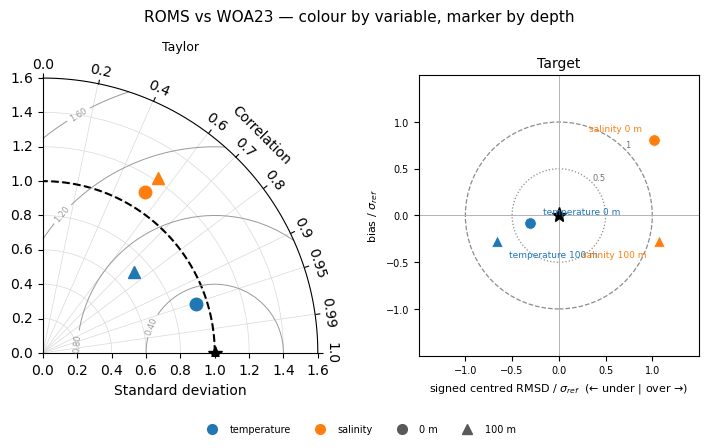

In [15]:
grouped = osk.compare(
    aggregate={"time": "mean"},
    reference=["woa23_temperature_month01", "woa23_salinity_month01"],
    test="roms_example_combined",
    variables=[TEMP, SALT],
    depths=(0, 100),
)
grouped.summary(
    title="ROMS vs WOA23 — colour by variable, marker by depth",
    color_by="variable", marker_by="depth",
);

Both diagrams are composable rather than monolithic: `taylor(fig=..., rect=...)` and
`target(ax=...)` draw into a figure you supply, and `paired()` is just the two of them
side by side. Styling is resolved once by a shared helper, so the panels always agree.

## 8. The escape hatch

The package owns the *standard, legible* comparisons. For anything bespoke, take the
prepared arrays and plot them yourself — they're aligned on a common grid, with the
difference and the regrid coverage fraction alongside.

In [16]:
aligned = depths[0].aligned
aligned

<xarray.Dataset> Size: 7kB
Dimensions:     (lon: 24, lat: 17)
Coordinates:
  * lon         (lon) float32 96B -100.5 -99.5 -98.5 -97.5 ... -79.5 -78.5 -77.5
  * lat         (lat) float32 68B 15.5 16.5 17.5 18.5 ... 28.5 29.5 30.5 31.5
    sigma_r     float32 4B dask.array<chunksize=(), meta=np.ndarray>
    Cs_r        float32 4B dask.array<chunksize=(), meta=np.ndarray>
    depth       float32 4B 0.0
    time        float32 4B 396.5
Data variables:
    test        (lat, lon) float32 2kB dask.array<chunksize=(17, 24), meta=np.ndarray>
    reference   (lat, lon) float32 2kB dask.array<chunksize=(17, 24), meta=np.ndarray>
    difference  (lat, lon) float32 2kB dask.array<chunksize=(17, 24), meta=np.ndarray>
    coverage    (lat, lon) float32 2kB dask.array<chunksize=(17, 24), meta=np.ndarray>
Attributes:
    regrid_method:   conservative_normed
    lon_convention:  -180-180
    min_coverage:    0.5

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
/var/folders/0f/07hq__ls2tdgjy7vykrfmmch0000gn/T/ipykernel_25697/764808071.py:9: SyntaxWarning: invalid escape sequence '\c'
  ax.set(xlabel="WOA23 [$^\circ$C]", ylabel="ROMS [$^\circ$C]",
/var/folders/0f/07hq__ls2tdgjy7vykrfmmch0000gn/T/ipykernel_25697/764808071.py:9: SyntaxWarning: invalid escape sequence '\c'
  ax.set(xlabel="WOA23 [$^\circ$C]", ylabel="ROMS [$^\circ$C]",


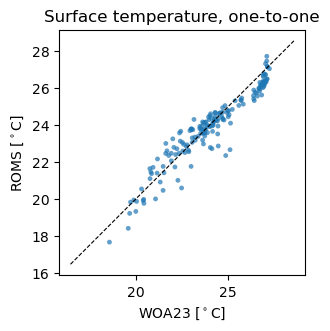

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 3.2), constrained_layout=True)
ax.scatter(aligned["reference"], aligned["test"], s=12, alpha=0.7, edgecolor="none")
lo = float(min(aligned["reference"].min(), aligned["test"].min()))
hi = float(max(aligned["reference"].max(), aligned["test"].max()))
lim = [lo, hi]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set(xlabel="WOA23 [$^\circ$C]", ylabel="ROMS [$^\circ$C]",
       title="Surface temperature, one-to-one")
ax.set_aspect("equal");

## 9. Knobs worth knowing

**Regridding.** The default is `conservative_normed`, which *area-averages* the fine
model onto the coarse observation cells — the right operator when the test is much finer
than the reference. `bilinear` samples instead, discarding subgrid structure. Plain
`conservative` divides by the whole destination cell area, so partly-covered edge cells
read artificially low; `conservative_normed` renormalizes, and cells covered less than
`min_coverage` (default 0.5) are dropped.

In [ ]:
osk.Comparison(aggregate={"time": "mean"}, reference="woa23_temperature_month01", test="roms_example_combined",
               variable=TEMP, select={"depth": 0},
               method="bilinear").metrics()["corr"]

0.9354246854782104

**Surface vs 0 m.** For a ROMS model, "the surface" is the topmost s-level. Interpolating
to *exactly* 0 m returns NaN, because the shallowest cell centre sits a few metres down —
`select={"depth": 0}` handles this for you by taking the top level, and
`roms.to_depth` warns if a requested level comes back empty.

**Coverage.** `metrics` warns when fewer than 30 cells survive — usually a sign the
reference is sparse over your domain. GLODAP is the cautionary case: it masks most
marginal seas and covers only ~8% of the Gulf of Mexico, so metrics against it there rest
on a couple of dozen cells. WOA covers ~58% of the same box.

## 10. Running it regularly

For recurring work, declare the comparison in YAML instead of code and run one command —
suitable for cron, CI, or a hook after each model checkpoint:

```bash
python -m ocean_skill.workflows.run suites/gom_nutrients.yaml
```

The suite deserializes into exactly the objects used above. Its `refresh:` block rebuilds
the model's kerchunk reference from whatever output exists at that moment, which is what
makes it safe to run against a simulation that is still writing.

```yaml
name: gom_surface_nutrients
output_dir: output/suites/gom_nutrients

refresh:                       # optional: re-scan the run's output first
  catalog: catalogs/gom_offline.yaml
  sources:
    - name: GOM_bgc
      files: <run>/output/output_bgc.*.nc
      grid:  <run>/input/input_datasets/..._grid.nc
      ref:   refs/gom_bgc.parquet

test: GOM_bgc
reference: [woa23_nitrate_month01, woa23_phosphate_month01]
variables:
  - mole_concentration_of_nitrate_in_sea_water
  - mole_concentration_of_phosphate_in_sea_water
depths: [0]
regrid: conservative_normed
plot:
  title: Surface nutrients — GOM vs WOA23
  filename: surface_nutrients.png
```

**Kerchunk references store byte offsets into specific files.** If the model rewrites or
rotates its output, an old reference fails with `ReferenceNotReachable` — hence the
refresh step. Rebuild it any time the output changes.

## 11. Adding your own data

Catalogs are built programmatically (intake v2 stores hashed references, so hand-writing
is impractical). Two calls:

```python
from ocean_skill.build import make_kerchunk, new_catalog, add_source, save

# one virtual store over a run's output, with the ROMS grid merged in
make_kerchunk(sorted(out.glob("output_bgc.*.nc")), "refs/my_run.parquet", grid=GRID)

cat = new_catalog(title="my run")
add_source(cat, "my_run", "refs/my_run.parquet")   # probes extents, axes, variables,
save(cat, "catalogs/my_run.yaml")                  # and guesses the featureType
```

`add_source` derives the metadata by *querying the data*: time/lon/lat/depth extents, the
cf-xarray axis mapping, variable→standard_name (falling back to a ROMS/MARBL table where
files lack `standard_name` attributes), and a featureType guess recorded alongside
`featureType_source` so you can see what was inferred rather than declared.

### Where to look next

- `examples/composing.py` — this notebook as a script
- `examples/gom_woa_nutrients.py`, `gom_woa_depths.py`, `gom_glodap_carbon.py` — the same
  comparisons written out step by step, useful when you want to see the plumbing
- `docs/interactive.ipynb` — the same plots rendered interactively, and static vs
  interactive side by side
- `docs/intake_v2_reference.md` — intake v2 catalog syntax, with the gotchas
- `ocean_skill/plot/summary.py` — the Taylor/Target implementations. Taylor is
  vendored from Yannick Copin's public-domain gist
  (<https://gist.github.com/ycopin/3342888>); Target follows Jolliff et al. (2009).